In [30]:
import matplotlib.pyplot
import pandas
from chronos import Chronos2Pipeline

import glob
from cycler import cycler

In [35]:
def read_summary_as_csv(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'core', 'event', 'value', 'enabled', 'running']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index('timestamp_ns').sort_index().fillna(1.0)

def transform_summary_csv(data_frame : pandas.DataFrame) -> pandas.DataFrame:
    wide_data_frame = data_frame.pivot_table(
        index=data_frame.index,
        columns=['core', 'event'],
        values=['value', 'enabled', 'running'],
    )
    scaled_data_frame = wide_data_frame['value'] * wide_data_frame['enabled'] / wide_data_frame['running']
    return scaled_data_frame.T.groupby(level='event').sum().T.sort_index(axis=1).resample("100ms").mean().diff()

def parse_vegeta_as_csv(file_path : str) -> pandas.DataFrame:
    columns : list[str] = ['timestamp_ns', 'status', 'latency_ns']
    data_frames : list[pandas.DataFrame] = [
        pandas.read_csv(log_file, usecols=[0, 1, 2], header=None, names=columns)
        for log_file in sorted(glob.glob(f"{file_path}/vegeta*.log"))
    ]
    combined_data_frame : pandas.DataFrame = pandas.concat(data_frames, ignore_index=True)

    combined_data_frame['timestamp_ns'] = pandas.to_datetime(combined_data_frame['timestamp_ns'], unit='ns')
    combined_data_frame = combined_data_frame.set_index('timestamp_ns')

    #return combined_data_frame['latency_ns'].resample('1s').quantile(0.99).expanding().mean() / 1e6
    return combined_data_frame['latency_ns'].resample('100ms').quantile(0.99) / 1e6

event,cache-misses,cpu-cycles,instructions,ref-cpu-cycles,rx_bytes,rx_packets,tx_bytes,tx_packets,p99_latency_ms
timestamp_ns,,,,,,,,,
2026-07-28 17:33:29.900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-28 17:33:30.000,6803.477778,1.921922e+08,4.861085e+07,3.065219e+08,0.0,0.0,0.0,0.0,NaN
2026-07-28 17:33:30.100,5952.800000,1.987378e+08,5.144342e+07,3.295891e+08,0.0,0.0,0.0,0.0,NaN
2026-07-28 17:33:30.200,5937.100000,1.991040e+08,5.098560e+07,3.275249e+08,0.0,0.0,0.0,0.0,NaN
2026-07-28 17:33:30.300,5968.800000,2.009488e+08,5.086670e+07,3.256702e+08,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
2026-07-28 17:51:54.500,4838.700000,1.960280e+08,5.007261e+07,3.236678e+08,0.0,0.0,0.0,0.0,8055.428343
2026-07-28 17:51:54.600,5012.500000,1.965767e+08,5.004768e+07,3.240338e+08,0.0,0.0,0.0,0.0,8055.428343
2026-07-28 17:51:54.700,5082.500000,1.963139e+08,5.014362e+07,3.255168e+08,0.0,0.0,0.0,0.0,8055.428343


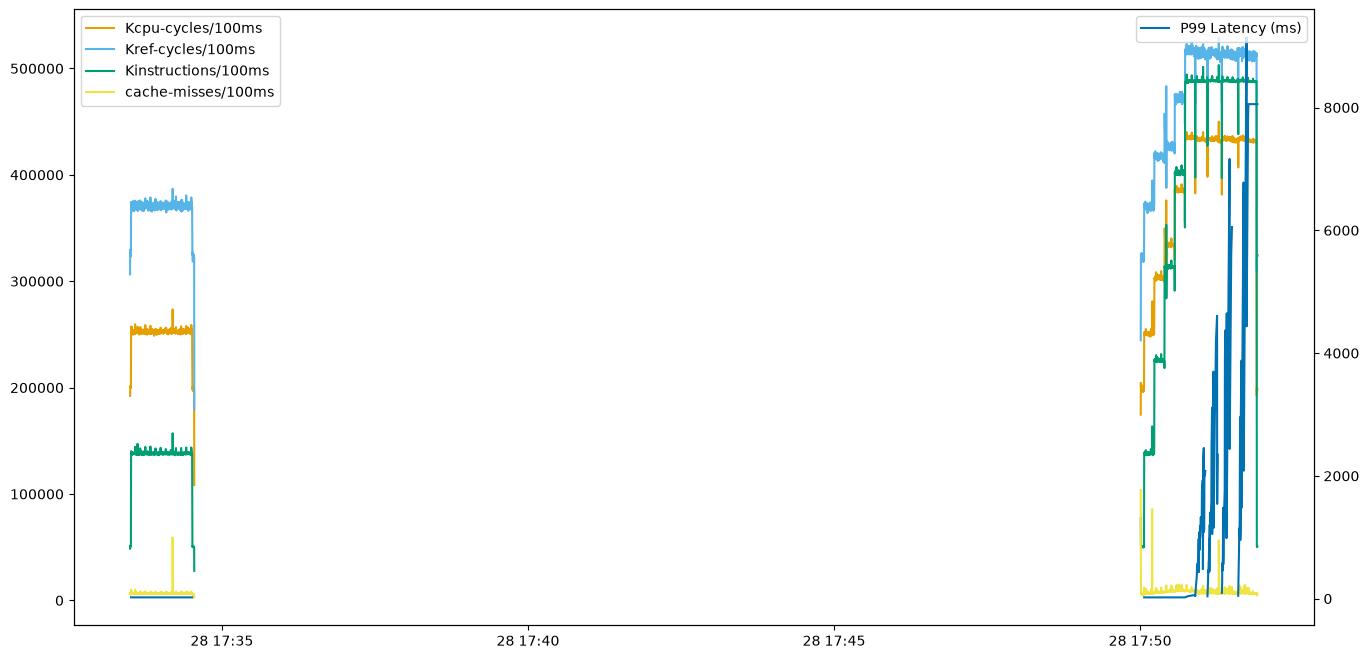

In [39]:
subdirectory=""

probe_data_frame  = transform_summary_csv(read_summary_as_csv(f"results/{subdirectory}summary.log"))

p99_latency_ms = parse_vegeta_as_csv(f"results/{subdirectory}")
probe_data_frame['p99_latency_ms'] = p99_latency_ms.reindex(probe_data_frame.index, method='ffill')

display(probe_data_frame)

figure, laxis = matplotlib.pyplot.subplots(figsize=(16, 8))
raxis = laxis.twinx()

laxis.set_prop_cycle(cycler(color=["#E69F00", "#56B4E9", "#009E73", "#F0E442"]))
raxis.set_prop_cycle(cycler(color=["#0072B2", "#D55E00", "#CC79A7", "#000000"]))

laxis.plot(probe_data_frame['cpu-cycles'] / 1e3,     label="Kcpu-cycles/100ms")
laxis.plot(probe_data_frame['ref-cpu-cycles'] / 1e3, label="Kref-cycles/100ms")
laxis.plot(probe_data_frame['instructions'] / 1e3,   label="Kinstructions/100ms")
laxis.plot(probe_data_frame['cache-misses'],         label="cache-misses/100ms")

raxis.plot(probe_data_frame['p99_latency_ms'], label="P99 Latency (ms)")

laxis.legend(loc="upper left")
raxis.legend(loc="upper right")

In [36]:
prediction_length = 50  # 5s of 100ms-resampled history, held out for backtesting

model_data_frame = probe_data_frame.dropna().reset_index().rename(columns={'timestamp_ns': 'timestamp'})
model_data_frame['item_id'] = "worker0"

train_data_frame = model_data_frame.iloc[:-prediction_length]
test_data_frame = model_data_frame.iloc[-prediction_length:]

display(train_data_frame)

event,timestamp,cache-misses,cpu-cycles,instructions,ref-cpu-cycles,rx_bytes,rx_packets,tx_bytes,tx_packets,p99_latency_ms,item_id
0,2026-07-28 17:33:30.900,9510.1,2.291580e+08,9.609570e+07,3.517417e+08,262.200001,2.6,163.2,2.4,21.609133,worker0
1,2026-07-28 17:33:31.000,10216.8,2.564279e+08,1.400550e+08,3.745246e+08,481.000000,5.0,338.0,5.0,21.145262,worker0
2,2026-07-28 17:33:31.100,7567.4,2.548488e+08,1.380116e+08,3.695776e+08,481.000000,5.0,338.0,5.0,21.099342,worker0
3,2026-07-28 17:33:31.200,7290.4,2.557486e+08,1.398212e+08,3.720426e+08,481.000000,5.0,338.0,5.0,20.982807,worker0
4,2026-07-28 17:33:31.300,6945.1,2.534420e+08,1.378073e+08,3.719085e+08,481.000000,5.0,338.0,5.0,20.923823,worker0
...,...,...,...,...,...,...,...,...,...,...,...
566,2026-07-28 17:34:27.500,6642.6,2.516270e+08,1.378783e+08,3.732495e+08,483.000000,5.0,338.0,5.0,20.898541,worker0
567,2026-07-28 17:34:27.600,6463.4,2.540746e+08,1.393980e+08,3.709054e+08,483.000000,5.0,338.0,5.0,20.803321,worker0
568,2026-07-28 17:34:27.700,6550.2,2.539314e+08,1.388481e+08,3.687816e+08,483.000000,5.0,338.0,5.0,20.753848,worker0
569,2026-07-28 17:34:27.800,6505.6,2.542797e+08,1.380120e+08,3.679868e+08,483.000000,5.0,338.0,5.0,20.908925,worker0


In [37]:
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2")

# All columns other than 'p99_latency_ms' (the perf/network counters) are passed through as
# past-only covariates, since their future values aren't known ahead of time.
forecast_data_frame = pipeline.predict_df(
    train_data_frame,
    id_column="item_id",
    timestamp_column="timestamp",
    target="p99_latency_ms",
    prediction_length=prediction_length,
)

display(forecast_data_frame)

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 14566.53it/s]


,item_id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,worker0,2026-07-28 17:34:28.000,p99_latency_ms,20.836332,20.751787,20.780893,20.802032,20.819853,20.836332,20.853230,20.870937,20.892509,20.922476
1,worker0,2026-07-28 17:34:28.100,p99_latency_ms,20.836199,20.751116,20.780121,20.801468,20.819447,20.836199,20.853149,20.870615,20.891943,20.921757
2,worker0,2026-07-28 17:34:28.200,p99_latency_ms,20.835440,20.748816,20.778395,20.800070,20.818460,20.835440,20.852694,20.870258,20.891459,20.921104
3,worker0,2026-07-28 17:34:28.300,p99_latency_ms,20.832342,20.748753,20.777872,20.798672,20.816208,20.832342,20.849367,20.867241,20.889572,20.920813
4,worker0,2026-07-28 17:34:28.400,p99_latency_ms,20.834764,20.750067,20.779890,20.801315,20.818758,20.834764,20.851654,20.869324,20.891146,20.922073
5,worker0,2026-07-28 17:34:28.500,p99_latency_ms,20.836365,20.750465,20.780230,20.801516,20.819569,20.836365,20.853823,20.871786,20.893698,20.924677
6,worker0,2026-07-28 17:34:28.600,p99_latency_ms,20.834639,20.749130,20.778210,20.799650,20.817629,20.834639,20.852348,20.870495,20.893011,20.924562
7,worker0,2026-07-28 17:34:28.700,p99_latency_ms,20.833385,20.748779,20.777723,20.798918,20.816729,20.833385,20.850998,20.869133,20.891649,20.923330
8,worker0,2026-07-28 17:34:28.800,p99_latency_ms,20.834974,20.749006,20.778440,20.799866,20.817989,20.834974,20.852556,20.870653,20.893009,20.924244
9,worker0,2026-07-28 17:34:28.900,p99_latency_ms,20.832499,20.749140,20.777924,20.798532,20.816128,20.832499,20.849447,20.867756,20.890482,20.922352


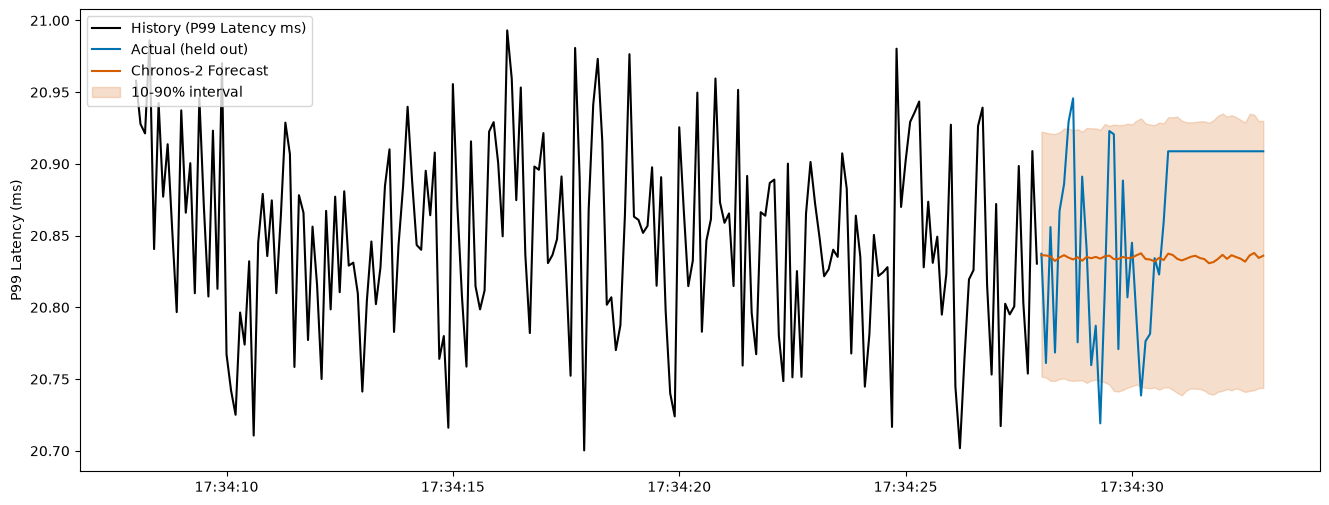

In [38]:
figure, axis = matplotlib.pyplot.subplots(figsize=(16, 6))

context_tail = train_data_frame.iloc[-200:]
axis.plot(context_tail['timestamp'], context_tail['p99_latency_ms'], label="History (P99 Latency ms)", color="#000000")
axis.plot(test_data_frame['timestamp'], test_data_frame['p99_latency_ms'], label="Actual (held out)", color="#0072B2")
axis.plot(forecast_data_frame['timestamp'], forecast_data_frame['predictions'], label="Chronos-2 Forecast", color="#D55E00")
axis.fill_between(
    forecast_data_frame['timestamp'],
    forecast_data_frame['0.1'],
    forecast_data_frame['0.9'],
    color="#D55E00",
    alpha=0.2,
    label="10-90% interval",
)

axis.set_ylabel("P99 Latency (ms)")
axis.legend(loc="upper left")